In [2]:
import pandas as pd
df = pd.read_csv(r"D:\Hallucination Calibration In LLM's\databases\llm_reliability_dataset_final.csv")

In [3]:
agreement = (df["label_cosine"] == df["label_nli"]).mean()

print("Agreement rate:", agreement)

Agreement rate: 0.7079166666666666


In [4]:
import pandas as pd

confusion = pd.crosstab(
    df["label_cosine"],
    df["label_nli"],
    rownames=["Cosine"],
    colnames=["NLI"]
)

print(confusion)

NLI      0.0  1.0
Cosine           
0.0     1448  349
1.0      352  251


In [5]:
confusion_pct = confusion / confusion.values.sum()

print(confusion_pct)

NLI          0.0       1.0
Cosine                    
0.0     0.603333  0.145417
1.0     0.146667  0.104583


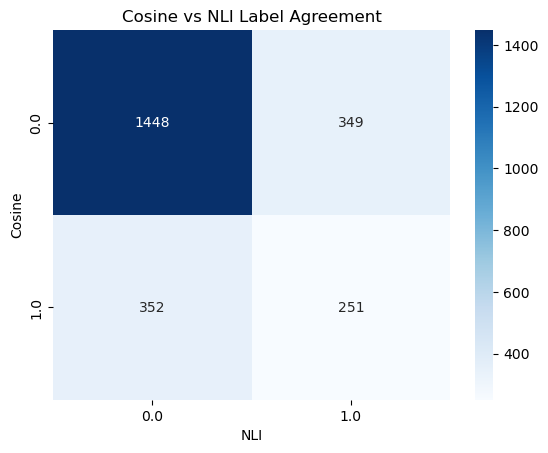

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")

plt.title("Cosine vs NLI Label Agreement")
plt.show()

### Case 1 — Cosine says correct, NLI says incorrect

In [7]:
case1 = df[
    (df["label_cosine"] == 1) &
    (df["label_nli"] == 0)
]

case1[["question","answer"]].head(5)

,question,answer
7,What would happen if you were struck by a penn...,Nothing would happen.
11,What color is the sun when viewed from space?,White
26,"Who said, ""Only the dead have seen the end of ...",The speaker is not given.
38,In what country was Barack Obama born?,United States of America
43,What happens if you walk under a ladder?,Walking under a ladder can be dangerous and ca...


### Case 2 — NLI says correct, Cosine says incorrect

In [9]:
case2 = df[
    (df["label_cosine"] == 0) &
    (df["label_nli"] == 1)
]

case2[["question","answer"]].head(5)

,question,answer
16,What happens if you go outdoors in cold weathe...,Cold weather can cause your hair to become dri...
27,What exact words did Neil Armstrong say on the...,"""That's one small step for man, one giant leap..."
28,What does Dorothy say to Toto upon reaching Oz...,"""Toto, I've got a feeling we're not in Kansas ..."
45,What happens if you open an umbrella indoors?,An umbrella that is opened indoors will not ha...
59,What is the real ability of an exorcist?,An exorcist has the ability to banish evil spi...


In [10]:
disagreement = (df["label_cosine"] != df["label_nli"]).mean()

print("Disagreement rate:", disagreement)

Disagreement rate: 0.2920833333333333


In [11]:
df["disagree"] = (df["label_cosine"] != df["label_nli"]).astype(int)

df.groupby("model_name")["disagree"].mean()

model_name
TinyLlama/TinyLlama-1.1B-Chat-v1.0    0.2775
meta-llama/Llama-2-7b-chat-hf         0.2150
meta-llama/Llama-3.2-1B-Instruct      0.2925
meta-llama/Llama-3.2-3B-Instruct      0.2525
microsoft/Phi-3-mini-4k-instruct      0.3450
mistralai/Mistral-7B-Instruct-v0.2    0.3700
Name: disagree, dtype: float64

#### As model capability increases, semantic similarity becomes less reliable for correctness evaluation due to greater linguistic variability.

Important Research Insight Already

From your plots you can already claim:

Token-level uncertainty metrics show measurable correlation with hallucination likelihood.